# `groundinsight` — topologies & parallel-path coefficients

Test bench for the topology classes covered by the solver:

1. **Line** — single path, `parallel_coefficient = 1`, analytical
   reduction factor.
2. **Symmetric ring** — two parallel paths, manual
   `parallel_coefficient = 0.5` on each branch.
3. **Symmetric ring** — same network, but use
   `auto_parallel_coefficients=True` so the solver derives the split
   from a phase-only pre-solve. Both ring variants must converge to
   the same reduction factor.
4. **Mixed** — cable / overhead line / cable in series. Reduction
   factor must lie strictly between the two limits (`R_REF < r < 1`).
5. **Large symmetric ring** — 20 cable-with-shield buses in a
   closed ring, source at one end, fault diametrically opposite.
   Verifies that the EPR profile decays away from the fault and
   rises again towards the source (mirror-symmetric profile).
6. **Frequency sweep** — same 20-bus ring, but the cable now has
   constant self- and mutual inductances (derived from the 50 Hz
   reference values). The reduction factor must decay monotonically
   and converge towards 0 as the frequency grows.

These are the same reference cases as the pytest suite in
`tests/test_topology_and_reduction.py`.


In [11]:
import sys
import os
# Make the src/ tree importable when running from the notebooks/ folder
project_root = os.path.abspath(os.path.join(os.getcwd(), '..', 'src'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import numpy as np
import polars as pl
import matplotlib.pyplot as plt

import groundinsight as gi
from groundinsight.models.core_models import BusType, BranchType, ComplexNumber

print('groundinsight', gi.__version__)


groundinsight 0.3.0


In [12]:
# Reference impedances (see tests/test_topology_and_reduction.py).
# With these values the analytical reduction factor for a single MV cable is
#     r = |1 - Z_mutual / Z_self| = 0.3846...
# which sits inside the field reference band of 0.30 ... 0.40.
Z_SELF   = complex(0.25, 0.6)
Z_MUTUAL = complex(0.0,  0.6)
R_REF    = abs(1.0 - Z_MUTUAL / Z_SELF)
print(f'analytical r = {R_REF:.4f}')


analytical r = 0.3846


In [13]:
def make_bus_type():
    """Unit bus impedance so the shield path dominates."""
    return BusType(
        name='BusUnit',
        description='Unit-like bus impedance for plausibility tests',
        system_type='Grounded',
        voltage_level=20.0,
        impedance_formula='rho * 0 + 1.0 + I * f * 0',
    )

def make_ms_cable():
    """MV cable with the reference impedances above."""
    return BranchType(
        name='MSCable',
        description='MV cable reference branch',
        grounding_conductor=True,
        self_impedance_formula='(rho * 0 + 0.25 + I * 0.6)*l',
        mutual_impedance_formula='(rho * 0 + 0.0 + I * 0.6)*l',
    )

def make_ohl():
    """Overhead line without shield."""
    return BranchType(
        name='OHLine',
        description='Overhead line without shield',
        grounding_conductor=False,
        self_impedance_formula='NaN',
        mutual_impedance_formula='NaN',
    )


## 1. Helper: build a single-path line

In [14]:
def build_line(name='Line'):
    net = gi.create_network(name=name, frequencies=[50])
    bus_type = make_bus_type()
    cable = make_ms_cable()
    for i in range(1, 4):
        gi.create_bus(name=f'bus{i}', type=bus_type, network=net)
    gi.create_branch(name='b12', type=cable, from_bus='bus1', to_bus='bus2',
                     length=1.0, network=net)
    gi.create_branch(name='b23', type=cable, from_bus='bus2', to_bus='bus3',
                     length=1.0, network=net)
    gi.create_source(name='src',   bus='bus1', values={50: 100.0}, network=net)
    gi.create_fault (name='fault', bus='bus3', scalings={50: 1.0},  network=net)
    return net

net_line = build_line()
gi.run_fault(net_line, fault_name='fault')
r_line = net_line.results['fault'].reduction_factor.value[50.0]
print(f'line:   r = {r_line:.4f}   (ref {R_REF:.4f})')
assert abs(r_line - R_REF) < 1e-3


line:   r = 0.3846   (ref 0.3846)


## 2. Symmetric ring with manual `parallel_coefficient = 0.5`

In [15]:
def build_symmetric_ring(name='Ring', parallel_coefficient=0.5):
    net = gi.create_network(name=name, frequencies=[50])
    bus_type = make_bus_type()
    cable = make_ms_cable()
    for i in range(1, 5):
        gi.create_bus(name=f'bus{i}', type=bus_type, network=net)
    # path A: bus1 -> bus2 -> bus3
    gi.create_branch(name='b12', type=cable, from_bus='bus1', to_bus='bus2',
                     length=1.0, network=net,
                     parallel_coefficient=parallel_coefficient)
    gi.create_branch(name='b23', type=cable, from_bus='bus2', to_bus='bus3',
                     length=1.0, network=net,
                     parallel_coefficient=parallel_coefficient)
    # path B: bus1 -> bus4 -> bus3
    gi.create_branch(name='b14', type=cable, from_bus='bus1', to_bus='bus4',
                     length=1.0, network=net,
                     parallel_coefficient=parallel_coefficient)
    gi.create_branch(name='b43', type=cable, from_bus='bus4', to_bus='bus3',
                     length=1.0, network=net,
                     parallel_coefficient=parallel_coefficient)
    gi.create_source(name='src',   bus='bus1', values={50: 100.0}, network=net)
    gi.create_fault (name='fault', bus='bus3', scalings={50: 1.0},  network=net)
    return net

net_ring = build_symmetric_ring()
gi.run_fault(net_ring, fault_name='fault')
r_ring = net_ring.results['fault'].reduction_factor.value[50.0]
print(f'ring (manual coeff 0.5):  r = {r_ring:.4f}   (ref {R_REF:.4f})')
assert abs(r_ring - R_REF) < 1e-3


ring (manual coeff 0.5):  r = 0.3846   (ref 0.3846)


## 3. Same ring, but with `auto_parallel_coefficients=True`

The solver runs a phase-only pre-solve to derive the split. The
manually set `parallel_coefficient` is intentionally overwritten with
`1.0` first, to prove the auto mode does not silently use it.


In [16]:
net_ring_auto = build_symmetric_ring(name='RingAuto', parallel_coefficient=1.0)
for branch in net_ring_auto.branches.values():
    branch.parallel_coefficient = 1.0  # reset (defensive)
gi.run_fault(net_ring_auto, fault_name='fault', auto_parallel_coefficients=True)
r_ring_auto = net_ring_auto.results['fault'].reduction_factor.value[50.0]
print(f'ring (auto split):        r = {r_ring_auto:.4f}   (ref {R_REF:.4f})')
assert abs(r_ring_auto - R_REF) < 1e-2


ring (auto split):        r = 0.3846   (ref 0.3846)


## 4. Mixed topology: cable / OHL / cable

The shieldless OHL section in the middle blocks the mutual coupling
on that segment. The reduction factor must therefore sit strictly
between the cable-only value (~0.385) and the OHL-only value (1.0).


In [17]:
def build_mixed():
    net = gi.create_network(name='Mixed', frequencies=[50])
    bus_type = make_bus_type()
    cable = make_ms_cable()
    ohl = make_ohl()
    for i in range(1, 5):
        gi.create_bus(name=f'bus{i}', type=bus_type, network=net)
    gi.create_branch(name='b12', type=cable, from_bus='bus1', to_bus='bus2',
                     length=1.0, network=net)
    gi.create_branch(name='b23', type=ohl,   from_bus='bus2', to_bus='bus3',
                     length=1.0, network=net)
    gi.create_branch(name='b34', type=cable, from_bus='bus3', to_bus='bus4',
                     length=1.0, network=net)
    gi.create_source(name='src',   bus='bus1', values={50: 100.0}, network=net)
    gi.create_fault (name='fault', bus='bus4', scalings={50: 1.0},  network=net)
    return net

net_mixed = build_mixed()
gi.run_fault(net_mixed, fault_name='fault')
r_mixed = net_mixed.results['fault'].reduction_factor.value[50.0]
print(f'mixed line:               r = {r_mixed:.4f}   '
      f'(must satisfy {R_REF:.3f} < r < 1)')
assert R_REF < r_mixed < 1.0


mixed line:               r = 0.9015   (must satisfy 0.385 < r < 1)


## 5. Large symmetric ring (20 buses, fault opposite source)

A closed ring with 20 buses, all branches are MV cables with shield
(`grounding_conductor=True`, mutual coupling active). The source sits
at `bus00` and the fault at `bus10`, i.e. exactly diametrically
opposite. The expected EPR profile is:

- maximum at the fault bus,
- monotonically decaying along each half of the ring as we move away
  from the fault,
- a local minimum somewhere between fault and source, then a
  moderate rise back up at the source bus where the shield current
  re-enters the local grounding system,
- mirror symmetry between the two halves of the ring (`bus_i` vs
  `bus_{N-i}`).


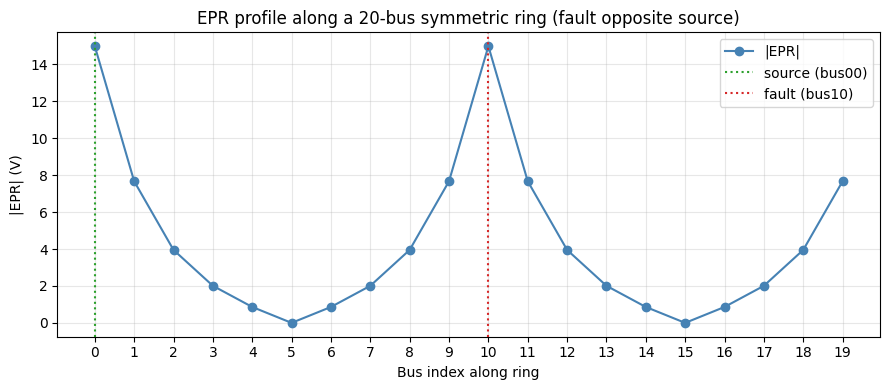

EPR minimum on the source-side half is at bus05 (between source 0 and fault 10)
mirror symmetry holds within 1e-6 * max(|EPR|)
source-bus EPR exceeds the half-ring minimum by 14.983 V (100.0% of fault EPR)

20-bus ring reduction factor: r = 0.3846


In [18]:
import re
import matplotlib.pyplot as plt

def build_large_ring(n_buses: int = 20, fault_offset: int | None = None,
                     name: str = 'Ring20'):
    """Closed ring of `n_buses` buses, all branches are MV cables with shield.

    Source is placed at bus00. The fault is placed `fault_offset` buses away
    along the ring; by default this is `n_buses // 2` (diametrically opposite).
    Each branch carries a manual `parallel_coefficient = 0.5` for the path-based
    mode; the auto mode below ignores it.
    """
    if fault_offset is None:
        fault_offset = n_buses // 2
    assert n_buses >= 4 and 0 < fault_offset < n_buses

    net = gi.create_network(name=name, frequencies=[50])
    bus_type = make_bus_type()
    cable = make_ms_cable()
    for i in range(n_buses):
        gi.create_bus(name=f'bus{i:02d}', type=bus_type, network=net)
    for i in range(n_buses):
        nxt = (i + 1) % n_buses
        gi.create_branch(
            name=f'b{i:02d}_{nxt:02d}', type=cable,
            from_bus=f'bus{i:02d}', to_bus=f'bus{nxt:02d}',
            length=1.0, network=net,
            parallel_coefficient=0.5,
        )
    gi.create_source(name='src',   bus='bus00',
                     values={50: 100.0}, network=net)
    gi.create_fault(name='fault', bus=f'bus{fault_offset:02d}',
                    scalings={50: 1.0}, network=net)
    return net, fault_offset

net_big, fault_idx = build_large_ring(n_buses=20)
# auto_parallel_coefficients=True derives the symmetric split from topology
gi.run_fault(net_big, fault_name='fault', auto_parallel_coefficients=True)

# --- Read EPR magnitude per bus, sort by bus index along the ring ---
result = net_big.results['fault']
def bus_index(name: str) -> int:
    m = re.match(r'bus(\d+)', name)
    return int(m.group(1)) if m else -1

epr = sorted(((bus_index(rb.name), rb.uepr) for rb in result.buses),
             key=lambda t: t[0])
indices = [i for i, _ in epr]
magnitudes = [u for _, u in epr]
mag_dict = dict(epr)
r_big = result.reduction_factor.value[50.0]

# --- Plot EPR(bus_index) ---
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(indices, magnitudes, 'o-', color='steelblue', label='|EPR|')
ax.axvline(0,         color='tab:green', ls=':', label='source (bus00)')
ax.axvline(fault_idx, color='tab:red',   ls=':', label=f'fault (bus{fault_idx:02d})')
ax.set_xlabel('Bus index along ring')
ax.set_ylabel('|EPR| (V)')
ax.set_title('EPR profile along a 20-bus symmetric ring (fault opposite source)')
ax.set_xticks(indices)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# --- Assertions: shape of the EPR profile ---
n = 20

# (b) along one half (bus 0 -> bus fault_idx) the EPR decays from the fault
#     and the minimum lies strictly between source and fault, not at either
#     endpoint -- i.e. the source-side rise is visible.
half = [mag_dict[i] for i in range(fault_idx + 1)]  # 0..fault_idx
min_pos = half.index(min(half))
print(f'EPR minimum on the source-side half is at bus{min_pos:02d} '
      f'(between source 0 and fault {fault_idx})')
assert 0 < min_pos < fault_idx, (
    f'EPR minimum should lie strictly between source and fault, '
    f'but is at bus{min_pos:02d}'
)

# (c) mirror symmetry: bus_i and bus_{N-i} have the same EPR
for i in range(1, n // 2):
    delta = abs(mag_dict[i] - mag_dict[n - i])
    assert delta < 1e-6 * max(magnitudes), (
        f'asymmetry at i={i}: |EPR[{i}] - EPR[{n - i}]| = {delta:.3e}'
    )
print('mirror symmetry holds within 1e-6 * max(|EPR|)')

# (d) source-side rise: EPR at the source bus is larger than the minimum
rise = mag_dict[0] - min(half)
rel_rise = rise / mag_dict[fault_idx]
print(f'source-bus EPR exceeds the half-ring minimum by '
      f'{rise:.3f} V ({rel_rise:.1%} of fault EPR)')
assert rise > 0, 'no rise at source bus -- check sign convention'

print(f'\n20-bus ring reduction factor: r = {r_big:.4f}')


## 6. Frequency sweep — reduction factor convergence

The MV cable used so far has a constant complex impedance taken at
50 Hz (`Z_self = 0.25 + j*0.6`, `Z_mutual = j*0.6`). To sweep the
frequency we re-interpret the imaginary parts as `omega * L_self` and
`omega * M`, treat the inductances as constants, and keep the resistive
part `R = 0.25 Ω/km` from the reference:

| symbol     | value                                | source                        |
|------------|--------------------------------------|-------------------------------|
| ω₅₀        | 2·π·50 ≈ 314.16 rad/s                | f = 50 Hz                     |
| L_self     | 0.6 / ω₅₀ ≈ **1.910 mH/km**          | from `Im(Z_self) = ωL`        |
| M          | 0.6 / ω₅₀ ≈ **1.910 mH/km**          | from `Im(Z_mutual) = ωM`      |
| R_self     | **0.25 Ω/km**                        | kept from 50 Hz reference     |
| k = M/L    | **1.0** (full coupling)              | by construction               |

Order of magnitude representative for a 20 kV XLPE cable with a 25 mm²
Cu shield. Writing the formula as `j*0.6*f/50` instead of `j*ω*L`
avoids dragging `π` through the SymPy formula string — it cancels
exactly: `ω·L = (2π·f) · (0.6/(2π·50)) = 0.6·f/50`.

The bus impedance stays purely resistive (`Z_bus = 1.0 Ω`,
frequency-independent — the formula `rho*0 + 1.0 + I*f*0` evaluates to
1.0 at any `f`).

Closed-form expectation for both a single cable and the symmetric
ring with the fault diametrically opposite the source
(`Z_mutual` perfectly anti-parallel to the source/fault injection):

$$
  r(f) \;=\; \bigl|\,1 - \tfrac{Z_{\text{mutual}}}{Z_{\text{self}}}\,\bigr|
         \;=\; \frac{R}{\sqrt{R^{2} + (\omega L)^{2}}}.
$$

For `f → ∞` the imaginary parts dominate, `Z_mutual / Z_self → M/L = 1`
and therefore `r → 0`.


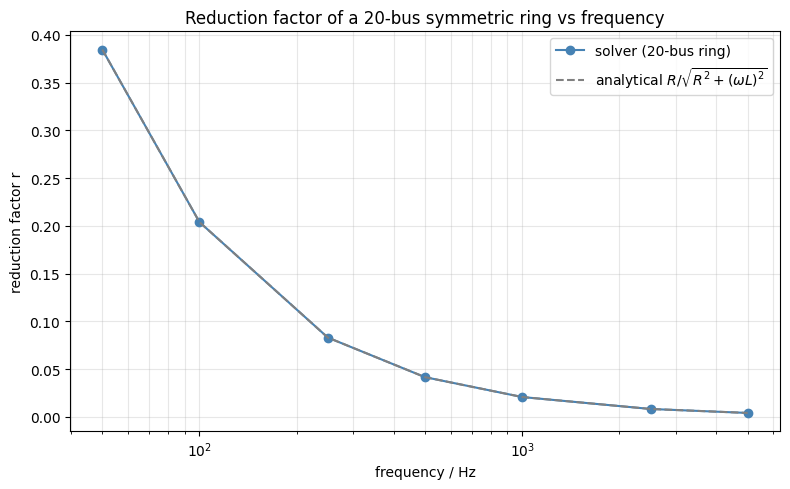

  f (Hz)    r (solver)   r (analyt.)     |delta|
      50      0.384615      0.384615    1.67e-16
     100      0.203954      0.203954    3.61e-16
     250      0.083045      0.083045    1.11e-16
     500      0.041631      0.041631    4.86e-17
    1000      0.020829      0.020829    2.43e-17
    2500      0.008333      0.008333    1.73e-18
    5000      0.004167      0.004167    6.07e-18

r(50 Hz)  = 0.3846
r(5 kHz)  = 0.00417  -> 1.1 % of the 50 Hz value


In [19]:
sweep_freqs = [50, 100, 250, 500, 1000, 2500, 5000]

def make_ms_cable_freq_dep():
    """Frequency-dependent MV cable with constant L_self == M.

    Z_self(f)   = 0.25 + j * 0.6 * (f / 50)   ohm / km
    Z_mutual(f) = 0.0  + j * 0.6 * (f / 50)   ohm / km

    Reproduces the 50 Hz reference exactly, scales linearly with f.
    """
    return BranchType(
        name='MSCableFreq',
        description='MV cable, frequency-dependent (constant L, M)',
        grounding_conductor=True,
        self_impedance_formula='(0.25 + I * 0.6 * f / 50) * l',
        mutual_impedance_formula='(0.0  + I * 0.6 * f / 50) * l',
    )

def r_analytical(f, R=0.25, R_omegaL_50=0.6):
    """r(f) = R / sqrt(R**2 + (omega*L)**2), with omega*L = 0.6*f/50."""
    omega_L = R_omegaL_50 * f / 50.0
    return R / np.sqrt(R**2 + omega_L**2)

def build_ring_sweep(n_buses: int = 20, freqs=sweep_freqs,
                     name: str = 'Ring20Sweep'):
    fault_offset = n_buses // 2
    net = gi.create_network(name=name, frequencies=freqs)
    bus_type = make_bus_type()
    cable = make_ms_cable_freq_dep()
    for i in range(n_buses):
        gi.create_bus(name=f'bus{i:02d}', type=bus_type, network=net)
    for i in range(n_buses):
        nxt = (i + 1) % n_buses
        gi.create_branch(
            name=f'b{i:02d}_{nxt:02d}', type=cable,
            from_bus=f'bus{i:02d}', to_bus=f'bus{nxt:02d}',
            length=1.0, network=net,
            parallel_coefficient=0.5,
        )
    gi.create_source(name='src', bus='bus00',
                     values={f: 100.0 for f in freqs}, network=net)
    gi.create_fault(name='fault', bus=f'bus{fault_offset:02d}',
                    scalings={f: 1.0 for f in freqs}, network=net)
    return net, fault_offset

net_sweep, _ = build_ring_sweep()
gi.run_fault(net_sweep, fault_name='fault',
             auto_parallel_coefficients=True)

rf = net_sweep.results['fault'].reduction_factor.value
r_solver = [rf[float(f)] for f in sweep_freqs]
r_ref    = [r_analytical(f) for f in sweep_freqs]
r_sweep_50 = r_solver[0]

# --- Plot r(f) on a logarithmic frequency axis ---
fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogx(sweep_freqs, r_solver, 'o-', color='steelblue',
            label='solver (20-bus ring)')
ax.semilogx(sweep_freqs, r_ref, '--', color='gray',
            label=r'analytical $R/\sqrt{R^2+(\omega L)^2}$')
ax.set_xlabel('frequency / Hz')
ax.set_ylabel('reduction factor r')
ax.set_title('Reduction factor of a 20-bus symmetric ring vs frequency')
ax.grid(which='both', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# --- Tabular comparison ---
print(f"{'f (Hz)':>8}  {'r (solver)':>12}  {'r (analyt.)':>12}  {'|delta|':>10}")
for f, r, ra in zip(sweep_freqs, r_solver, r_ref):
    print(f"{f:>8.0f}  {r:>12.6f}  {ra:>12.6f}  {abs(r-ra):>10.2e}")

# --- Assertions ---
for prev, curr in zip(r_solver, r_solver[1:]):
    assert curr < prev, f'r is not monotonically decreasing: {r_solver}'
assert r_solver[-1] < 0.05, (
    f'r({sweep_freqs[-1]} Hz) = {r_solver[-1]:.4f} should be below 5 %'
)
for f, r, ra in zip(sweep_freqs, r_solver, r_ref):
    assert abs(r - ra) / max(ra, 1e-9) < 1e-3, (
        f'solver deviates from analytical at f={f} Hz: '
        f'{r:.6f} vs {ra:.6f}'
    )

print(
    f'\nr(50 Hz)  = {r_solver[0]:.4f}\n'
    f'r(5 kHz)  = {r_solver[-1]:.5f}  '
    f'-> {r_solver[-1] / r_solver[0] * 100:.1f} % of the 50 Hz value'
)


## 7. Summary table


In [20]:
summary = pl.DataFrame({
    'topology': [
        'line (single path)',
        'ring (manual 0.5)',
        'ring (auto split)',
        'mixed (cable/OHL/cable)',
        '20-bus ring (auto split)',
        '20-bus ring sweep @ 50 Hz',
    ],
    'r':     [r_line, r_ring, r_ring_auto, r_mixed, r_big, r_sweep_50],
    'r_ref': [R_REF,  R_REF,  R_REF,        float('nan'),
              float('nan'), R_REF],
})
summary = summary.with_columns(
    (pl.col('r') - pl.col('r_ref')).abs().alias('|delta|')
)
print(summary)


shape: (6, 4)
┌───────────────────────────┬──────────┬──────────┬────────────┐
│ topology                  ┆ r        ┆ r_ref    ┆ |delta|    │
│ ---                       ┆ ---      ┆ ---      ┆ ---        │
│ str                       ┆ f64      ┆ f64      ┆ f64        │
╞═══════════════════════════╪══════════╪══════════╪════════════╡
│ line (single path)        ┆ 0.384615 ┆ 0.384615 ┆ 0.0        │
│ ring (manual 0.5)         ┆ 0.384615 ┆ 0.384615 ┆ 0.0        │
│ ring (auto split)         ┆ 0.384615 ┆ 0.384615 ┆ 5.5511e-17 │
│ mixed (cable/OHL/cable)   ┆ 0.901523 ┆ NaN      ┆ NaN        │
│ 20-bus ring (auto split)  ┆ 0.384615 ┆ NaN      ┆ NaN        │
│ 20-bus ring sweep @ 50 Hz ┆ 0.384615 ┆ 0.384615 ┆ 2.2204e-16 │
└───────────────────────────┴──────────┴──────────┴────────────┘


---

**What this exercises**

- Path-based mutual-coupling direction (root cause of the bug fixed
  in 0.3.0).
- Both the manual `parallel_coefficient` route and the
  `auto_parallel_coefficients` route in `run_fault`.
- The OHL-only / cable-only / mixed limits as sanity bounds.
